In [9]:
import cv2
import numpy as np

def video_to_array(video_path, radius=1):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        # Convert BGR to grayscale and keep only one channel
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        if radius > 1:
            from scipy.ndimage import maximum_filter
            frame = maximum_filter(frame, size=radius)
        frames.append(frame)
    cap.release()
    frames = np.array(frames)
    # print(f"Min value: {frames.min()}, Max value: {frames.max()}")
    # Reshape to (t,c,h,w) format
    return frames[:, None, :, :]

# Load videos as numpy arrays
input_frames = video_to_array('/workspace_bk/piyush/results/facl/CONVLSTM_HKO7/201501070000_in.mp4', radius=4)
output_frames = video_to_array('/workspace_bk/piyush/results/facl/CONVLSTM_HKO7/201501070000_out.mp4', radius=4)
pred_frames = video_to_array('/workspace_bk/piyush/results/facl/CONVLSTM_HKO7/201501070000_pred.mp4', radius=4)
output_frames = output_frames[:-1]
pred_frames = pred_frames[:-1]

# Checked results with text overlays, the mp4's have an extra frame for pred and out at the end, for an unexplainable reason
# input_frames = video_to_array('/workspace_bk/piyush/results/hko7_convlstm_trajgru_saveall/trajGRU_balanced_mse_mae//201501070000_in.mp4')
# output_frames = video_to_array('/workspace_bk/piyush/results/hko7_convlstm_trajgru_saveall/trajGRU_balanced_mse_mae/201501070000_out.mp4')
# pred_frames = video_to_array('/workspace_bk/piyush/results/hko7_convlstm_trajgru_saveall/trajGRU_balanced_mse_mae/201501070000_pred.mp4')


In [10]:
print(input_frames.shape, output_frames.shape, pred_frames.shape)

(5, 1, 480, 480) (20, 1, 480, 480) (20, 1, 480, 480)


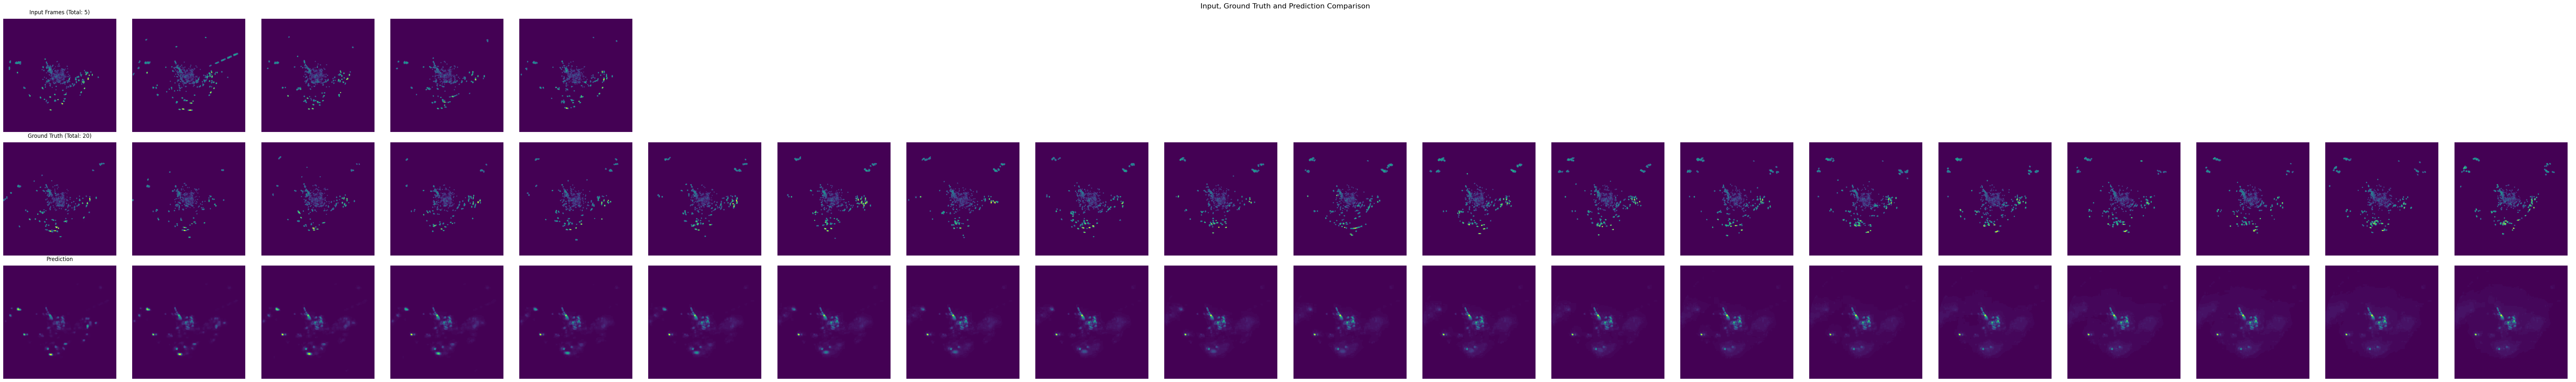

Number of input frames: 5
Number of output/prediction frames: 20


In [11]:
import matplotlib.pyplot as plt

# Get number of frames for input vs output/pred
n_input_frames = len(input_frames)
n_output_frames = len(output_frames) # Same as prediction frames

# Calculate number of columns needed based on max frames
n_cols = max(n_input_frames, n_output_frames)

# Create figure with 3 rows (input, output, prediction)
fig, axes = plt.subplots(3, n_cols, figsize=(4*n_cols, 12))
fig.suptitle('Input, Ground Truth and Prediction Comparison', fontsize=16)

# Plot input frames
for i in range(n_cols):
    if i < n_input_frames:
        # Reshape from (c,h,w) to (h,w)
        frame = input_frames[i].squeeze()
        axes[0, i].imshow(frame)
        axes[0, i].set_xlabel(f'Frame {i}')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title(f'Input Frames (Total: {n_input_frames})', pad=10)

# Plot ground truth output frames  
for i in range(n_cols):
    if i < n_output_frames:
        # Reshape from (c,h,w) to (h,w)
        frame = output_frames[i].squeeze()
        axes[1, i].imshow(frame)
        axes[1, i].set_xlabel(f'Frame {i}')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title(f'Ground Truth (Total: {n_output_frames})', pad=10)

# Plot prediction frames
for i in range(n_cols):
    if i < n_output_frames:
        # Reshape from (c,h,w) to (h,w)
        frame = pred_frames[i].squeeze()
        axes[2, i].imshow(frame)
        axes[2, i].set_xlabel(f'Frame {i}')
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_title('Prediction', pad=10)

plt.tight_layout()
plt.show()

print(f"Number of input frames: {n_input_frames}")
print(f"Number of output/prediction frames: {n_output_frames}")


In [243]:
def mae(*args):
    return np.mean(np.abs(args[0] - args[1]))

def mse(*args):
    return np.mean((args[0] - args[1])**2)

def tfpn(y_pred, y, threshold, radius=1):
    '''
    Convert numpy arrays to binary and compute confusion matrix values
    '''
    if radius > 1:
        from scipy.ndimage import maximum_filter
        y = maximum_filter(y, size=radius)
        y_pred = maximum_filter(y_pred, size=radius)
    
    y = np.where(y >= threshold, 1, 0)
    y_pred = np.where(y_pred >= threshold, 1, 0)
    
    tp = np.sum((y_pred == 1) & (y == 1))
    tn = np.sum((y_pred == 0) & (y == 0))
    fp = np.sum((y_pred == 1) & (y == 0))
    fn = np.sum((y_pred == 0) & (y == 1))
    return tp, tn, fp, fn

def csi(tp, tn, fp, fn):
    '''Critical Success Index. The larger the better.'''
    if (tp + fn + fp) < 1e-7:
        return 0.
    return tp / (tp + fn + fp)

def csi_4(tp, tn, fp, fn):
    return csi(tp, tn, fp, fn)

def csi_16(tp, tn, fp, fn):
    return csi(tp, tn, fp, fn)

def far(tp, tn, fp, fn):
    '''False Alarm Rate. The smaller the better.'''
    if (tp + fp) < 1e-7:
        return 0.   
    return fp / (tp + fp)

def pod(tp, tn, fp, fn):
    '''Probability of Detection (ML: Recall). The larger the better.'''
    if (tp + fn) < 1e-7:
        return 0.    
    return tp / (tp + fn)

def ssim(y_pred, y):
    from skimage.metrics import structural_similarity
    if y.ndim == 4:
        b, t, h, w = y.shape
        y = y.reshape(b*t, h, w)
        y_pred = y_pred.reshape(b*t, h, w)
    
    # Ensure values are in [0,1]
    y = np.clip(y, 0, 1)
    y_pred = np.clip(y_pred, 0, 1)
    
    score = 0
    for i in range(len(y)):
        score += structural_similarity(y[i], y_pred[i], data_range=1.0)
    return score / len(y)

def psnr(y_pred, y):
    from skimage.metrics import peak_signal_noise_ratio
    if y.ndim == 4:
        b, t, h, w = y.shape
        y = y.reshape(b*t, h, w)
        y_pred = y_pred.reshape(b*t, h, w)
    
    score = 0
    for i in range(len(y)):
        score += peak_signal_noise_ratio(y[i], y_pred[i], data_range=1.0)
    return score / len(y)

def inception_score(y_pred, y):
    raise NotImplementedError()

def fid(y_pred, y):
    raise NotImplementedError()

def lpips(y_pred, y, net='vgg'):
    '''
    Note: LPIPS still requires torch tensors internally, so we convert numpy arrays
    '''
    import torch
    import lpips as lp
    
    # Convert to torch tensors
    y = torch.from_numpy(y).float()
    y_pred = torch.from_numpy(y_pred).float()
    
    # Reshape if needed
    if y.ndim == 4:
        b, t, h, w = y.shape
        y = y.reshape(-1, 1, h, w)
        y_pred = y_pred.reshape(-1, 1, h, w)
    
    # Scale to [-1,1]
    y = (2 * y - 1)
    y_pred = (2 * y_pred - 1)
    
    # Use LPIPS
    global GLOBAL_LPIPS_OBJ
    if GLOBAL_LPIPS_OBJ is None:
        GLOBAL_LPIPS_OBJ = lp.LPIPS(net=net)
        if torch.cuda.is_available():
            GLOBAL_LPIPS_OBJ = GLOBAL_LPIPS_OBJ.cuda()
            y = y.cuda()
            y_pred = y_pred.cuda()
    
    with torch.no_grad():
        score = GLOBAL_LPIPS_OBJ(y_pred, y).mean().cpu().numpy()
    return score

In [244]:
class MetricListEvaluator():    
    '''
    To evaluate a list of metrics. Supported metrics:
    - CSI (Eg. `csi-84`)
    - POD (Eg. `pod-84`)
    - FAR (Eg. `far-84`)
    - MAE
    - MSE
    - SSIM
    - PSNR    
    '''
    def __init__(self, metric_list, out_len):        
        self.metric_holder = {}
        self.batch_count = 0
        self.out_len = out_len
        for metric_name in metric_list:
            threshold = ''
            if '-' in metric_name:
                metric_name, threshold = metric_name.split('-')
            # initialize metrics
            key_name = metric_name + (f'-{threshold}' if len(threshold) > 0 else '')
            threshold = float(threshold) / 255 if threshold.isdigit() else threshold
            self.metric_holder[key_name] = self.init_metric(metric_name, threshold=threshold)
    
    def init_metric(self, metric_name, **kwarg):
        '''
        return a tuple of three items in order:
        - the function to call during eval
        - the value(s) to keep track of
        - a dict of any additional item to pass into the function
        '''        
        if metric_name in ['csi', 'pod', 'far']:
            # use tfpn instead
            return [tfpn, np.zeros((self.out_len, 4), dtype=np.float32), {'threshold': kwarg['threshold']}] # tp, 
        elif metric_name == 'csi_4':
            # tfpn with radius (pooling)
            return [tfpn, np.zeros((self.out_len, 4), dtype=np.float32), {'threshold': kwarg['threshold'], 'radius': 4}]
        elif metric_name == 'csi_16':
            return [tfpn, np.zeros((self.out_len, 4), dtype=np.float32), {'threshold': kwarg['threshold'], 'radius': 16}]
        else:
            # directly convert the string name into function call
            return [eval(metric_name), 0, {}]

    def eval(self, y_pred, y):
        self.batch_count += 1
        for metric_name, metric in self.metric_holder.items():
            # temp = metric[0](y_pred, y, **metric[-1])      
            # if temp is list:
            #     temp = np.array(temp)
            # # elif type(temp) == torch.Tensor:
            # #     temp = temp.detach().cpu().numpy()
            # metric[1] += temp
            if '-' in metric_name: 
                for i in range(self.out_len):
                    temp_y_pred = y_pred[i, :, :, :]
                    temp_y = y[i, :, :, :]
                    temp = metric[0](temp_y_pred, temp_y, **metric[-1])   
                    if isinstance(temp, list):
                        temp = np.array(temp)
                    # elif isinstance(temp, torch.Tensor):
                    #     temp = temp.detach().cpu().numpy()
                    # print(metric[1].shape, temp)
                    metric[1][i] += temp
            else:
                temp = metric[0](y_pred, y, **metric[-1])      
                if temp is list:
                    temp = np.array(temp)
                # elif type(temp) == torch.Tensor:
                #     temp = temp.detach().cpu().numpy()
                metric[1] += temp                

    def get_results(self):
        print(self.batch_count)
        output_holder = {}
        for key, metric in self.metric_holder.items():
            val = metric[1]
            # special handle of tfpn => compute the final score now
            if metric[0] is tfpn:
                metric_name, threshold = key.split('-')
                val = val[:,0]
                for i in range(self.out_len):
                    # print(list(metric[1][i]))
                    val[i] = eval(metric_name)(*list(metric[1][i]))
            else:
                val /= self.batch_count if self.batch_count > 0 else 1
            output_holder[key] = val
        return output_holder

In [245]:
# metric_list = ['mae', 'mse', 'ssim', 'psnr', 'csi-84', 'csi-117', 'csi-140', 'csi-158', 'csi-185', 
#                 'csi_4-84', 'csi_4-117', 'csi_4-140', 'csi_4-158', 'csi_4-185', 
#                 'csi_16-84', 'csi_16-117', 'csi_16-140', 'csi_16-158', 'csi_16-185',
#                 'pod-84', 'far-84']
metric_list = ['mae', 'mse', 'ssim', 'psnr', 'csi-84', 'csi-117', 'csi-140', 'csi-158', 'csi-185', 'pod-84', 'far-84', 'lpips']
evaluator = MetricListEvaluator(metric_list, out_len=20)

In [246]:
import os
import glob
from tqdm import tqdm

# Get all files in the directory
dir_path = '/workspace_bk/piyush/results/facl/CONVLSTM_HKO7'
file_pattern = os.path.join(dir_path, '*_pred.mp4')
pred_files = glob.glob(file_pattern)

# Process each set of files
count = 0
for pred_file in tqdm(pred_files, desc='Processing videos'):
    # Get corresponding input and output files
    base_name = pred_file[:-9] # Remove '_pred.mp4'
    input_file = base_name + '_in.mp4'
    output_file = base_name + '_out.mp4'
    
    # Load the videos
    pred_frames = video_to_array(pred_file)
    output_frames = video_to_array(output_file)
    
    # Remove last frame and normalize
    pred_frames = pred_frames[:-1] / 255
    output_frames = output_frames[:-1] / 255
    
    # Evaluate
    evaluator.eval(pred_frames, output_frames)
    
    count += 1
    if count >= 20:
        break

Processing videos:   0%|          | 0/6053 [00:00<?, ?it/s]


UnboundLocalError: local variable 'GLOBAL_LPIPS_OBJ' referenced before assignment

In [232]:
final_results = evaluator.get_results()
for k, v in final_results.items():
    print(f'{k}: {v}')

20
mae: 0.033528464945874185
mse: 0.008000991721433263
ssim: 0.671993721137569
psnr: 23.48093827448404
csi-84: [0.7386465  0.69082093 0.6462391  0.6123279  0.5826044  0.55841523
 0.53561604 0.5209782  0.50442576 0.49044168 0.47762153 0.46467504
 0.45045412 0.4390509  0.4288884  0.41803014 0.40715763 0.39714473
 0.3867457  0.3762967 ]
csi-117: [0.72961044 0.6727199  0.6205475  0.580106   0.5410768  0.5119414
 0.4829395  0.4604428  0.43665951 0.41551733 0.39620224 0.37949127
 0.36525106 0.3518537  0.3339931  0.31901148 0.30074528 0.27948675
 0.2604359  0.24058442]
csi-140: [0.653997   0.5907451  0.52859557 0.48438698 0.4352541  0.39548227
 0.35541034 0.32141936 0.2880176  0.2674577  0.24565762 0.22786894
 0.20787704 0.19082049 0.17022155 0.15112743 0.12811875 0.10595212
 0.08919213 0.07050212]
csi-158: [0.55487674 0.47404984 0.40185857 0.34177902 0.28231403 0.23844504
 0.1935286  0.15443905 0.11847008 0.0931053  0.07369979 0.06193281
 0.05367418 0.0435664  0.03513229 0.02875631 0.0263743